In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [178]:
# Load metadata
df = pd.read_csv('../../input_data/whole_genome_metadata/grad_lab_complete_genomes_metadata.csv', index_col = 0)

# Get additional metadata on gender and merge with other metadata
metadata = pd.read_csv("../../input_data/lab_strains_hybrid_genomes_metadata.csv", index_col = 0)
metadata = metadata[['wgs_id', 'gender']]
merged = df.merge(metadata, on = 'wgs_id', how = 'left')

# Get year and decade from date
merged['year'] = merged['biosample_collection_date'].str.split('-', expand = True)[0].astype('float')
merged['decade'] = merged['year'].astype('float') - (merged['year'].astype('float')%10)

# Fill NaNs with NA for continent and gender
merged[['continent', 'gender']] = merged[['continent', 'gender']].fillna(value='NA')

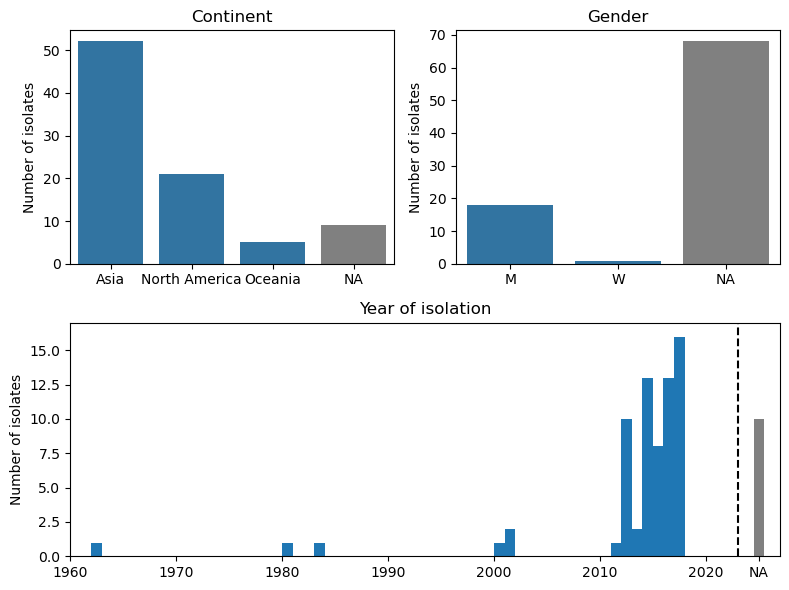

In [286]:
# Set up subplots: 2 on top and 1 on bottom
fig, ax = plt.subplots(2,2,figsize = (8,6))#3, width_ratios = [1, 1, 3])

for a in ax[1, :]:
    a.remove()

gs = ax[0, 0].get_gridspec()
ax3 = fig.add_subplot(gs[1, :])   # second row, all columns

# PLOT CONTINENTS

# Get order of values for plot
values = np.unique(merged['continent'])
# Mask of non-NaN values
mask = values!='NA'
# New array with NaNs moved to the end
order = np.concatenate([values[mask], values[~mask]])

sns.countplot(merged, x = 'continent', order = order, color = 'tab:blue', ax = ax[0,0])

# Set NaN bar gray
ax[0,0].patches[-1].set_facecolor("gray")

ax[0,0].set_xlabel('')
ax[0,0].set_title('Continent')
ax[0,0].set_ylabel('Number of isolates')

# PLOT GENDERS

# Get order of values for plot
values = np.unique(merged['gender'])
# Mask of non-NaN values
mask = values!='NA'
# New array with NaNs moved to the end
order = np.concatenate([values[mask], values[~mask]])

sns.countplot(merged, x = 'gender', order = order, color = 'tab:blue', ax = ax[0,1])

# Set NaN bar gray
ax[0,1].patches[-1].set_facecolor("gray")

ax[0,1].set_xlabel('')
ax[0,1].set_title('Gender')
ax[0,1].set_ylabel('Number of isolates')

# PLOT YEARS

# Get an array of the years as floats
year_float = merged['year'].values
# Number of years with "NA"
num_year_na = np.isnan(year_float).sum()

# Plot valid years
n, bins, patches = ax3.hist(year_float, np.arange(np.nanmin(year_float), np.nanmax(year_float)))

# Place the NA bar
bin_width = bins[1] - bins[0]
x_nan_center = 2025 # x position of the NaN bar center
ax3.bar(x_nan_center, n_nan, width=bin_width, color = 'gray')

# Put a tick label for the NaN bar
ax3.set_xticks(list(ax3.get_xticks()) + [x_nan_center])
ax3.set_xticklabels(
    [lab for lab in ax3.get_xticks().astype('int')[:-1]] + ['NA'],  # simple relabel; adjust as needed
    rotation=0
)

# Add divider for NA bar for visual clarity
ax3.plot([2023, 2023], [0, 17], 'k--')

ax3.set_xlim([1960, 2027])
ax3.set_ylim([0, 17])
ax3.set_ylabel("Number of isolates")
ax3.set_title("Year of isolation")

plt.tight_layout()

plt.savefig('../../figures/assembly_summary/grad_lab_genomes_metadata.png', dpi = 300)
plt.savefig('../../figures/assembly_summary/grad_lab_genomes_metadata.pdf')

plt.show()